# TP1 — Análisis de eventos globales con GDELT 2.0

**Materia:** Ingeniería de Datos

Se analizan los eventos registrados en todo el mundo por el proyecto
[GDELT 2.0](https://blog.gdeltproject.org/gdelt-2-0-our-global-world-in-realtime/),
calculando medidas diarias a partir del **2 de septiembre de 2026**.

---

## Declaración de uso de Inteligencia Artificial

| Herramienta | Propósito |
|---|---|
| **Gemini 2.5 Flash** | Generación de la versión inicial del código fuente (descarga y parseo de los archivos de GDELT) y redacción preliminar de los textos. |
| **Claude Opus 5** | Revisión y corrección del código: detección de un error en el mapeo de columnas del `export.CSV`, extensión del cálculo a la serie diaria completa, optimización del acceso a los datos (descarga paralela y agregación incremental) y revisión de la redacción. |

Todas las decisiones metodológicas, la validación de los resultados contra el
*codebook* oficial y la interpretación final son de elaboración propia.

## Actividad 1 — Estrategia de acceso a los datos

> *"Accedan a los datos de la forma más eficiente posible. Fundamenten sus decisiones."*

**a) ¿Qué archivos usar?** GDELT 2.0 publica cada 15 minutos tres archivos distintos:
`export.CSV` (tabla de eventos), `mentions.CSV` (cada mención de un evento en un artículo)
y `gkg.csv` (Global Knowledge Graph). Usamos **únicamente `export.CSV`** porque contiene una
fila por evento y ya trae precalculados los campos `NumArticles` y `NumSources`. Reconstruir
esos conteos desde `mentions.CSV` implicaría descargar y agrupar un volumen de datos
mucho mayor para llegar exactamente al mismo resultado.

**b) ¿Cómo obtener la lista de archivos?** La `masterfilelist.txt` pesa ~127 MB y tiene
~1,19 millones de líneas. En lugar de cargarla entera en memoria con `response.text`,
la recorremos **en streaming** (`stream=True` + `iter_lines()`) y filtramos línea por línea,
construyendo en **una sola pasada** un índice `fecha -> [urls]`. Esto evita mantener las
1,19 M de URLs en memoria y evita recorrer la lista una vez por cada día analizado.

**c) ¿Qué columnas leer?** El `export.CSV` tiene 61 columnas, pero solo necesitamos 4.
Se usa `usecols` en `pd.read_csv` para parsear exclusivamente esas columnas: el resto del
archivo ni siquiera se convierte a objetos de Python.

**d) Descarga en paralelo.** Cada día son 96 archivos (24 h × 4) y el rango completo supera
los 800. La latencia de red domina el tiempo total, así que se descargan de a 16 en paralelo
con `ThreadPoolExecutor`. El trabajo es I/O-bound, por lo que los hilos no sufren el GIL.

**e) Agregación incremental.** No se concatenan todos los eventos en un único DataFrame.
De cada archivo se extraen solo los **acumuladores necesarios** (cantidad de filas, suma de
artículos, suma de fuentes) y se descartan las filas. La memoria pasa de ser proporcional a
la cantidad de eventos (~1 millón) a ser proporcional a la cantidad de archivos.

**f) Sin escritura a disco.** Los ZIP se descomprimen en memoria con `io.BytesIO`, evitando
el I/O de disco y el manejo de archivos temporales.

**g) Robustez.** Se usa una `Session` con reintentos y *backoff* exponencial, y se lleva la
cuenta de los archivos efectivamente procesados frente a los esperados. Un archivo que falle
en silencio subestimaría la cantidad de eventos del día, así que cualquier faltante se reporta.

In [1]:
import io
import zipfile
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from datetime import date, timedelta

import numpy as np
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# --- Configuración -----------------------------------------------------------
MASTER_FILE_LIST_URL = "https://data.gdeltproject.org/gdeltv2/masterfilelist.txt"

FECHA_INICIO = date(2026, 9, 2)    # consigna: "medidas diarias desde 2 Sep 2026"
FECHA_FIN    = date(2026, 9, 10)   # fecha de la entrega, fija para que el resultado sea reproducible

ARCHIVOS_POR_DIA = 96             # 24 h x 4 archivos por hora (uno cada 15 min)
MAX_WORKERS      = 16             # descargas concurrentes

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print(f"Rango de análisis: {FECHA_INICIO} -> {FECHA_FIN}")
print(f"pandas {pd.__version__}")

Rango de análisis: 2026-09-02 -> 2026-09-10
pandas 3.0.5


In [2]:
def crear_session() -> requests.Session:
    """Session HTTP con reintentos y backoff exponencial.

    Sobre ~800 descargas, un 5xx o un corte transitorio es esperable. Sin reintentos
    perderíamos archivos silenciosamente y subestimaríamos los eventos del día.
    """
    session = requests.Session()
    retry = Retry(
        total=4,
        backoff_factor=1.0,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=("GET",),
    )
    session.mount("https://", HTTPAdapter(max_retries=retry, pool_maxsize=MAX_WORKERS))
    session.mount("http://",  HTTPAdapter(max_retries=retry, pool_maxsize=MAX_WORKERS))
    return session

SESSION = crear_session()
print("Session HTTP configurada.")

Session HTTP configurada.


## Paso 1 — Índice de archivos por fecha (lectura en streaming)

La `masterfilelist.txt` tiene el formato `<tamaño> <checksum> <url>` por línea. La recorremos
sin materializarla en memoria y nos quedamos solo con los `export.CSV.zip` del rango pedido.

In [3]:
def indexar_archivos(fecha_inicio: date, fecha_fin: date) -> dict[str, list[str]]:
    """Devuelve {'YYYYMMDD': [urls de export.CSV.zip]} para el rango indicado.

    Recorre la masterfilelist en streaming: nunca se cargan los ~127 MB en memoria
    ni se guardan las ~1,19 M de URLs que no interesan.
    """
    fechas_objetivo = set()
    d = fecha_inicio
    while d <= fecha_fin:
        fechas_objetivo.add(d.strftime("%Y%m%d"))
        d += timedelta(days=1)

    indice: dict[str, list[str]] = defaultdict(list)
    lineas = 0

    with SESSION.get(MASTER_FILE_LIST_URL, stream=True, timeout=300) as resp:
        resp.raise_for_status()
        for raw in resp.iter_lines(decode_unicode=True):
            if not raw:
                continue
            lineas += 1
            partes = raw.split()          # .split() y no .split(' '): robusto a espacios múltiples
            if len(partes) != 3:
                continue
            url = partes[2]
            nombre = url.rsplit("/", 1)[-1]
            if not nombre.endswith(".export.CSV.zip"):
                continue
            fecha = nombre[:8]
            if fecha in fechas_objetivo:
                indice[fecha].append(url)

    print(f"Líneas recorridas en la masterfilelist: {lineas:,}")
    return {f: sorted(u) for f, u in sorted(indice.items())}


indice_archivos = indexar_archivos(FECHA_INICIO, FECHA_FIN)

print(f"Días encontrados: {len(indice_archivos)}\n")
for fecha, urls in indice_archivos.items():
    estado = "completo" if len(urls) == ARCHIVOS_POR_DIA else "PARCIAL"
    print(f"  {fecha}: {len(urls):>3} archivos  ({estado})")

Líneas recorridas en la masterfilelist: 1,194,126
Días encontrados: 9

  20260902:  96 archivos  (completo)
  20260903:  96 archivos  (completo)
  20260904:  96 archivos  (completo)
  20260905:  96 archivos  (completo)
  20260906:  96 archivos  (completo)
  20260907:  96 archivos  (completo)
  20260908:  96 archivos  (completo)
  20260909:  96 archivos  (completo)
  20260910:  91 archivos  (PARCIAL)


## Paso 2 — Columnas del `export.CSV` según el *codebook*

Este es el punto donde es fácil equivocarse: el `export.CSV` **no tiene encabezado**, así que
las columnas se identifican por posición. Según el
[GDELT 2.0 Event Codebook](https://data.gdeltproject.org/documentation/GDELT-Event_Codebook-V2.0.pdf),
las posiciones relevantes (0-indexadas) son:

| Índice | Campo | Descripción |
|---:|---|---|
| 0 | `GlobalEventID` | Identificador único del evento. Se usa para validar que no haya duplicados. |
| 1 | `Day` (`SQLDATE`) | Fecha del **evento** en formato `YYYYMMDD` (puede ser anterior a la de publicación). |
| 30 | *GoldsteinScale* | ⚠️ No confundir con los conteos. |
| 31 | *NumMentions* | ⚠️ Cantidad de **menciones**, no de fuentes. |
| **32** | **`NumSources`** | Cantidad de fuentes de información distintas que mencionan el evento. |
| **33** | **`NumArticles`** | Cantidad de artículos que mencionan el evento. |

> **Validación de sanidad:** `NumArticles` y `NumSources` son conteos enteros y valen
> **como mínimo 1** (un evento existe porque al menos un artículo lo reportó). Si un promedio
> diario diera menor que 1, la columna leída sería la equivocada.

In [4]:
COLS_IDX    = [0, 1, 32, 33]
COLS_NOMBRE = ["GlobalEventID", "Day", "NumSources", "NumArticles"]
COLS_DTYPE  = {
    "GlobalEventID": "int64",
    "Day": "int32",
    "NumSources": "int32",   # conteos enteros, nunca nulos ni fraccionarios
    "NumArticles": "int32",
}

# Verificación empírica sobre un archivo real antes de procesar todo el rango.
_url_muestra = indice_archivos[FECHA_INICIO.strftime("%Y%m%d")][0]
_r = SESSION.get(_url_muestra, timeout=90)
_r.raise_for_status()
with zipfile.ZipFile(io.BytesIO(_r.content)) as _z:
    _muestra = pd.read_csv(_z.open(_z.namelist()[0]), sep="\t", header=None)

print(f"Archivo de muestra : {_url_muestra.rsplit('/', 1)[-1]}")
print(f"Dimensiones        : {_muestra.shape[0]} filas x {_muestra.shape[1]} columnas")
print(f"Columnas esperadas : 61 -> {'OK' if _muestra.shape[1] == 61 else 'ERROR'}\n")

_chequeo = _muestra.iloc[:5, [0, 1, 30, 31, 32, 33]]
_chequeo.columns = ["GlobalEventID", "Day", "GoldsteinScale(30)",
                    "NumMentions(31)", "NumSources(32)", "NumArticles(33)"]
print("Primeras filas de las columnas de interés:")
print(_chequeo.to_string(index=False))

assert (_muestra[32] >= 1).all(), "NumSources debería ser >= 1"
assert (_muestra[33] >= 1).all(), "NumArticles debería ser >= 1"
assert _muestra[30].between(-10, 10).all(), "La col. 30 es GoldsteinScale (rango -10 a 10)"
print("\nValidaciones de columnas: OK")

Archivo de muestra : 20260902000000.export.CSV.zip
Dimensiones        : 2408 filas x 61 columnas
Columnas esperadas : 61 -> OK

Primeras filas de las columnas de interés:
 GlobalEventID      Day  GoldsteinScale(30)  NumMentions(31)  NumSources(32)  NumArticles(33)
    1321003469 20250902                -5.0                3               1                3
    1321003470 20250902                -5.0               20               2               20
    1321003471 20250902                 0.0                5               1                5
    1321003472 20250902                -4.4               60               6               60
    1321003473 20260803                -2.0                2               1                2

Validaciones de columnas: OK


## Paso 3 — Procesamiento paralelo con agregación incremental

De cada archivo se extraen únicamente los acumuladores necesarios y se descartan las filas.
Se conservan los `GlobalEventID` del día (≈1 MB por día) para verificar que no haya eventos
duplicados entre archivos.

In [5]:
def procesar_archivo(url: str) -> dict | None:
    """Descarga un .zip, lo descomprime en memoria y devuelve solo los acumuladores."""
    try:
        r = SESSION.get(url, timeout=120)
        r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            nombre_csv = z.namelist()[0]
            with z.open(nombre_csv) as f:
                df = pd.read_csv(
                    f, sep="\t", header=None,
                    usecols=COLS_IDX, names=COLS_NOMBRE, dtype=COLS_DTYPE,
                )
    except Exception as e:
        print(f"  [!] Falló {url.rsplit('/', 1)[-1]}: {type(e).__name__}: {e}")
        return None

    fecha_archivo = int(url.rsplit("/", 1)[-1][:8])
    return {
        "n_eventos":     len(df),
        "suma_articulos": int(df["NumArticles"].sum()),
        "suma_fuentes":   int(df["NumSources"].sum()),
        "n_sqldate_igual": int((df["Day"] == fecha_archivo).sum()),
        "ids":            df["GlobalEventID"].to_numpy(),
    }


def procesar_dia(fecha: str, urls: list[str]) -> dict:
    """Agrega los 96 archivos de un día. Los promedios se calculan sobre los totales
    del día (suma / cantidad de eventos), NO promediando los promedios por archivo:
    los archivos no contienen la misma cantidad de eventos."""
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        parciales = [p for p in ex.map(procesar_archivo, urls) if p is not None]

    n_eventos      = sum(p["n_eventos"] for p in parciales)
    suma_articulos = sum(p["suma_articulos"] for p in parciales)
    suma_fuentes   = sum(p["suma_fuentes"] for p in parciales)
    sqldate_igual  = sum(p["n_sqldate_igual"] for p in parciales)
    ids            = np.concatenate([p["ids"] for p in parciales]) if parciales else np.array([])

    return {
        "fecha":                          pd.to_datetime(fecha, format="%Y%m%d"),
        "cantidad_eventos":               n_eventos,
        "promedio_articulos_por_evento":  suma_articulos / n_eventos if n_eventos else np.nan,
        "promedio_fuentes_por_evento":    suma_fuentes / n_eventos if n_eventos else np.nan,
        "archivos_esperados":             len(urls),
        "archivos_procesados":            len(parciales),
        "dia_completo":                   len(urls) == ARCHIVOS_POR_DIA and len(parciales) == len(urls),
        "eventos_unicos":                 int(np.unique(ids).size),
        "eventos_con_sqldate_del_dia":    sqldate_igual,
    }

print("Funciones de procesamiento definidas.")

Funciones de procesamiento definidas.


In [6]:
import time

filas = []
t0 = time.perf_counter()

for fecha, urls in indice_archivos.items():
    t_dia = time.perf_counter()
    fila = procesar_dia(fecha, urls)
    filas.append(fila)
    print(f"{fecha} | {fila['archivos_procesados']:>3}/{fila['archivos_esperados']:>3} archivos "
          f"| {fila['cantidad_eventos']:>7,} eventos "
          f"| {time.perf_counter() - t_dia:5.1f} s")

print(f"\nTiempo total: {time.perf_counter() - t0:.1f} s")

20260902 |  96/ 96 archivos | 120,105 eventos |   1.5 s
20260903 |  96/ 96 archivos | 117,020 eventos |   0.9 s
20260904 |  96/ 96 archivos | 107,037 eventos |   0.7 s
20260905 |  96/ 96 archivos |  66,878 eventos |   0.8 s
20260906 |  96/ 96 archivos |  60,454 eventos |   0.8 s
20260907 |  96/ 96 archivos |  86,043 eventos |   0.9 s
20260908 |  96/ 96 archivos | 114,917 eventos |   0.9 s
20260909 |  96/ 96 archivos | 119,065 eventos |   0.8 s
20260910 |  91/ 91 archivos | 112,534 eventos |   0.9 s

Tiempo total: 8.2 s


## Actividad 3 — Resultados como DataFrame de Pandas

In [7]:
df_resultados = pd.DataFrame(filas)

# Métricas pedidas por la consigna
df_medidas = df_resultados[[
    "fecha",
    "cantidad_eventos",
    "promedio_articulos_por_evento",
    "promedio_fuentes_por_evento",
]].copy()

df_medidas = df_medidas.set_index("fecha").round(4)
df_medidas.index.name = "Fecha"
df_medidas.columns = [
    "Cantidad de eventos",
    "Promedio de artículos por evento",
    "Promedio de fuentes por evento",
]

display(df_medidas)

,Cantidad de eventos,Promedio de artículos por evento,Promedio de fuentes por evento
Fecha,,,
2026-09-02,120105,4.6422,1.0485
2026-09-03,117020,4.6300,1.0455
2026-09-04,107037,4.6868,1.0470
2026-09-05,66878,4.6408,1.0399
2026-09-06,60454,4.5743,1.0438
2026-09-07,86043,4.6777,1.0403
2026-09-08,114917,4.6019,1.0470
2026-09-09,119065,4.6253,1.0419
2026-09-10,112534,4.6063,1.0441


## Visualización de resultados

Tres gráficos de barras, uno por medida. Decisiones de diseño:

- **Eje vertical desde cero en los tres.** Recortar el eje para "ampliar" diferencias
  pequeñas exagera visualmente la variación; en los promedios la estabilidad *es* el
  hallazgo, y con el eje completo se ve tal cual es.
- **Un solo color por gráfico.** Los días no son categorías distintas: son la misma
  medida a lo largo del tiempo. Colorear cada barra de un color distinto (o degradadas
  por altura) duplicaría en el color una información que la altura ya da.
- **El día parcial (10/09) va en un paso más claro del mismo azul** y rotulado como
  "parcial", para que no se lea como una caída o una subida real de volumen.
- **Etiquetas selectivas:** solo el máximo, el mínimo y el día parcial llevan el valor
  escrito. El resto se lee en el eje y en la tabla de arriba, que funciona como
  vista tabular accesible del gráfico.

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path

# --- Paleta -------------------------------------------------------------------
SUPERFICIE  = "#fcfcfb"   # superficie del gráfico
TINTA       = "#0b0b0b"   # texto primario
TINTA_SEC   = "#52514e"   # texto secundario
TINTA_TENUE = "#898781"   # ejes y ticks
GRILLA      = "#e1e0d9"   # grilla (hairline)
EJE         = "#c3c2b7"   # línea de base
AZUL        = "#2a78d6"   # color de la serie
AZUL_CLARO  = "#86b6ef"   # mismo tono, paso claro -> día parcial

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "savefig.bbox": "tight",
    "font.size": 9, "text.color": TINTA, "axes.labelcolor": TINTA_SEC,
    "xtick.color": TINTA_TENUE, "ytick.color": TINTA_TENUE,
    "figure.dpi": 120,
})


def _barras_redondeadas(ax, alturas, colores, ancho, radio_px=4):
    # Barras con el extremo de datos redondeado (4 px) y escuadra en la base.
    # Requiere que los límites del eje ya estén fijados: el radio se define en
    # píxeles y se convierte a unidades de datos.
    inv = ax.transData.inverted()
    (x0, y0), (x1, y1) = inv.transform([(0, 0), (radio_px, radio_px)])
    rx, ry = x1 - x0, y1 - y0
    for xi, (h, c) in enumerate(zip(alturas, colores)):
        izq, der = xi - ancho / 2, xi + ancho / 2
        r_x, r_y = min(rx, ancho / 2), min(ry, h / 2)
        verts = [(izq, 0), (izq, h - r_y), (izq, h), (izq + r_x, h),
                 (der - r_x, h), (der, h), (der, h - r_y), (der, 0), (izq, 0)]
        codes = [Path.MOVETO, Path.LINETO, Path.CURVE3, Path.CURVE3,
                 Path.LINETO, Path.CURVE3, Path.CURVE3, Path.LINETO, Path.CLOSEPOLY]
        ax.add_patch(PathPatch(Path(verts, codes), facecolor=c, edgecolor="none", zorder=3))


def grafico_barras(ax, etiquetas, valores, titulo, subtitulo, fmt, idx_parcial,
                   ancho=0.30, fmt_etiqueta=None):
    fmt_etiqueta = fmt_etiqueta or fmt
    valores = list(valores)
    n = len(valores)
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_ylim(0, max(valores) * 1.20)          # aire arriba para las etiquetas

    colores = [AZUL_CLARO if i == idx_parcial else AZUL for i in range(n)]
    _barras_redondeadas(ax, valores, colores, ancho)

    # Grilla hairline sólida por detrás de las barras; sin marco
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRILLA, linewidth=0.8, solid_capstyle="butt")
    ax.xaxis.grid(False)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(EJE)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(length=0, labelsize=8.5)

    ax.set_xticks(range(n))
    ax.set_xticklabels(etiquetas)
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: fmt(v)))

    # Etiquetas directas: solo máximo, mínimo y día parcial
    i_max, i_min = valores.index(max(valores)), valores.index(min(valores))
    for i in sorted({i_max, i_min, idx_parcial}):
        texto = fmt_etiqueta(valores[i]) + ("\nparcial" if i == idx_parcial else "")
        ax.annotate(texto, (i, valores[i]), xytext=(0, 6), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8.2,
                    color=TINTA_SEC if i == idx_parcial else TINTA,
                    linespacing=1.35)

    ax.set_title(titulo, loc="left", fontsize=11, color=TINTA, pad=26, fontweight="bold")
    ax.text(0, 1.045, subtitulo, transform=ax.transAxes,
            fontsize=8.5, color=TINTA_SEC, va="bottom")


# Datos para graficar
etiquetas   = [f.strftime("%d/%m") for f in df_resultados["fecha"]]
idx_parcial = int(df_resultados.index[~df_resultados["dia_completo"]][0])

miles   = lambda v: f"{v:,.0f}".replace(",", ".")
decimal  = lambda v: f"{v:.2f}".replace(".", ",")
decimal3 = lambda v: f"{v:.3f}".replace(".", ",")

print(f"Día parcial destacado: {etiquetas[idx_parcial]} (índice {idx_parcial})")

Día parcial destacado: 10/09 (índice 8)


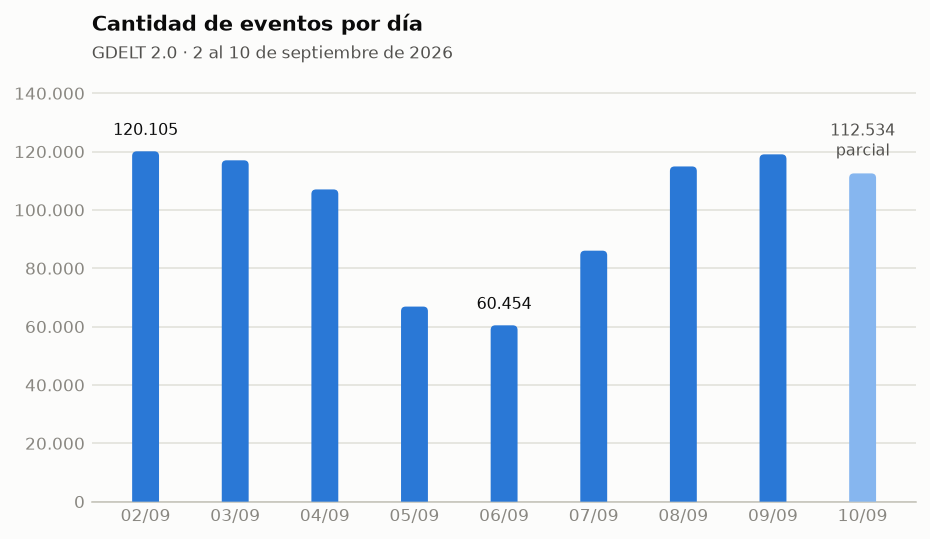

In [9]:
fig, ax = plt.subplots(figsize=(7.6, 3.9))
grafico_barras(
    ax, etiquetas, df_resultados["cantidad_eventos"],
    "Cantidad de eventos por día",
    "GDELT 2.0 · 2 al 10 de septiembre de 2026",
    miles, idx_parcial,
)
plt.show()

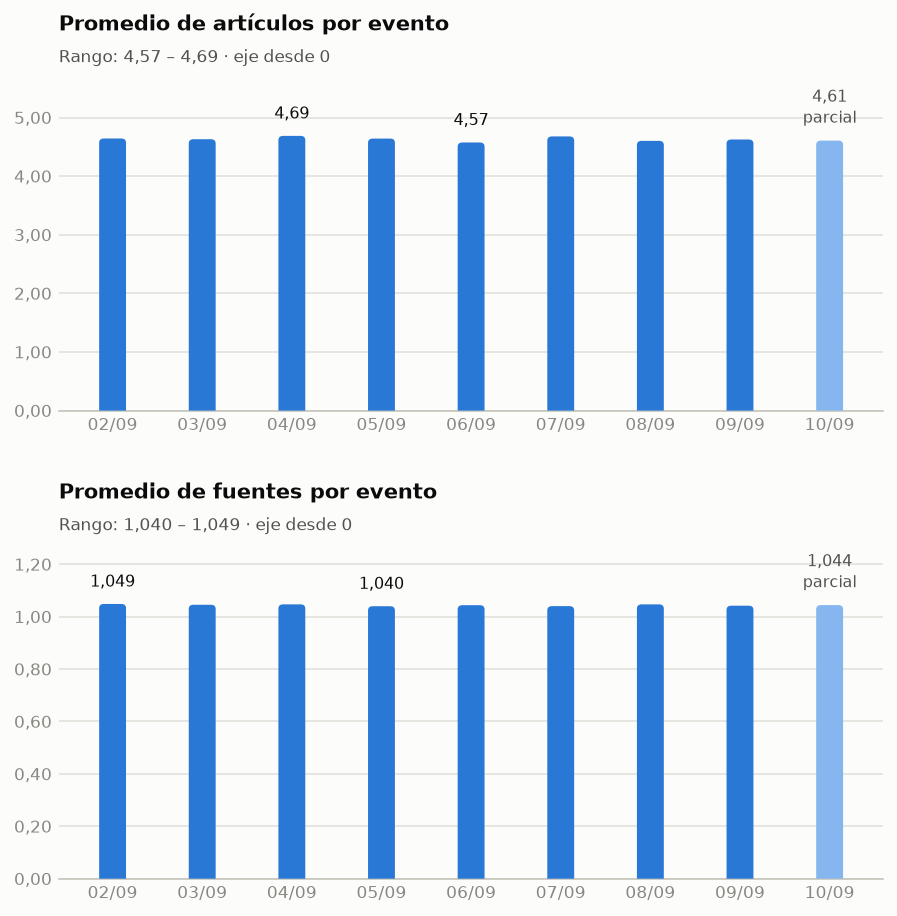

In [10]:
# Paneles apilados y no lado a lado: en dos columnas las etiquetas del eje x se solapan.
fig, axes = plt.subplots(2, 1, figsize=(7.6, 7.4))

art = df_resultados["promedio_articulos_por_evento"]
grafico_barras(
    axes[0], etiquetas, art,
    "Promedio de artículos por evento",
    f"Rango: {decimal(art.min())} – {decimal(art.max())} · eje desde 0",
    decimal, idx_parcial,
)

fue = df_resultados["promedio_fuentes_por_evento"]
grafico_barras(
    axes[1], etiquetas, fue,
    "Promedio de fuentes por evento",
    f"Rango: {decimal3(fue.min())} – {decimal3(fue.max())} · eje desde 0",
    decimal, idx_parcial, fmt_etiqueta=decimal3,
)

fig.subplots_adjust(hspace=0.42)
plt.show()

### Lectura de los gráficos

- **Volumen de eventos:** el 5 y 6 de septiembre caen a la mitad respecto del resto
  (60.454 y 66.878 frente a ~120.000). Corresponden a **sábado y domingo**: es la
  estacionalidad semanal esperable en la cobertura de noticias, y funciona como
  chequeo de que los datos se están leyendo bien.
- **Artículos por evento:** se mantiene entre 4,57 y 4,69 durante los nueve días.
  Una variación menor al 3% indica que, aunque el volumen de eventos se desplome el
  fin de semana, la **cobertura por evento no cambia**: se reportan menos eventos, no
  eventos peor cubiertos.
- **Fuentes por evento:** prácticamente constante en ~1,04. La enorme mayoría de los
  eventos son reportados por **una sola fuente**, aun cuando en promedio los mencionen
  4,6 artículos: varios artículos del mismo medio cubriendo un mismo hecho.

## Validaciones y notas metodológicas

Se reportan los controles de calidad que respaldan la tabla anterior.

In [11]:
df_control = df_resultados[[
    "fecha", "archivos_esperados", "archivos_procesados", "dia_completo",
    "cantidad_eventos", "eventos_unicos", "eventos_con_sqldate_del_dia",
]].copy()
df_control["pct_sqldate_del_dia"] = (
    100 * df_control["eventos_con_sqldate_del_dia"] / df_control["cantidad_eventos"]
).round(2)
df_control["fecha"] = df_control["fecha"].dt.date

print("Control de completitud e integridad:\n")
print(df_control.to_string(index=False))

faltantes = (df_control["archivos_esperados"] - df_control["archivos_procesados"]).sum()
duplicados = (df_control["cantidad_eventos"] - df_control["eventos_unicos"]).sum()
print(f"\nArchivos no procesados en todo el rango : {faltantes}")
print(f"GlobalEventID duplicados en todo el rango: {duplicados}")
parciales = [f.strftime("%Y-%m-%d") for f in df_control.loc[~df_resultados["dia_completo"], "fecha"]]
print(f"Días con datos parciales                 : {', '.join(parciales) if parciales else 'ninguno'}")

Control de completitud e integridad:

     fecha  archivos_esperados  archivos_procesados  dia_completo  cantidad_eventos  eventos_unicos  eventos_con_sqldate_del_dia  pct_sqldate_del_dia
2026-09-02                  96                   96          True            120105          120105                       117696                97.99
2026-09-03                  96                   96          True            117020          117020                       114504                97.85
2026-09-04                  96                   96          True            107037          107037                       104882                97.99
2026-09-05                  96                   96          True             66878           66878                        65683                98.21
2026-09-06                  96                   96          True             60454           60454                        59399                98.25
2026-09-07                  96                   96          T

### Decisiones metodológicas

**1. Criterio de "día": fecha de publicación, no fecha del evento.**
Cada evento tiene dos fechas: la del archivo de 15 minutos en que GDELT lo publica y el campo
`SQLDATE` (columna 1), que es la fecha en que el evento *ocurrió*. Se agrupó por **fecha de
publicación**, que es la lectura natural de la consigna dado que el recurso indicado es la
lista de archivos actualizada cada 15 minutos. La columna `pct_sqldate_del_dia` muestra que
la enorme mayoría de los eventos publicados en un día ocurrieron ese mismo día; el resto son
eventos anteriores que GDELT incorpora con retraso o reprocesa.

**2. No hay eventos duplicados.** Cada `GlobalEventID` aparece una sola vez dentro del rango
analizado, por lo que `cantidad_eventos` coincide con `eventos_unicos` y no hizo falta
deduplicar.

**3. Días parciales.** Un día completo tiene 96 archivos. El rango termina el **10/09/2026**,
que es el día en que se ejecutó el análisis y por lo tanto está incompleto: su
`cantidad de eventos` **no es comparable** con la de los días completos. Los promedios de ese
día sí lo son, porque son ratios y no dependen de cuántos archivos se hayan publicado. La
columna `dia_completo` permite identificar estos casos. `FECHA_FIN` está fijada de forma
explícita (en lugar de usar `date.today()`) para que el notebook sea reproducible: reejecutarlo
en otra fecha devuelve exactamente la misma tabla.

**4. Promedios sobre totales del día.** Los promedios se calculan como
`suma_del_día / eventos_del_día`, y no como el promedio de los promedios de cada archivo,
porque los archivos de 15 minutos no contienen la misma cantidad de eventos.

---

### Fuentes

- GDELT 2.0 Event Database — <https://blog.gdeltproject.org/gdelt-2-0-our-global-world-in-realtime/>
- GDELT 2.0 Event Codebook — <https://data.gdeltproject.org/documentation/GDELT-Event_Codebook-V2.0.pdf>
- CAMEO Manual 1.1b3 — <https://gdeltproject.org/data/documentation/CAMEO.Manual.1.1b3.pdf>